In [1]:
import pandas as pd
import numpy as np  
import xgboost as xgb
import optuna
from optuna_integration import XGBoostPruningCallback
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
import os
import joblib
from pathlib import Path

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "NO2"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")   
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
# reading in data
base_path = os.getenv("BASE_DATA_PATH")
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(base_path, file_name)

In [6]:
# saving results
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# saving model
model_filename = output_dir / f"xgboost_model_{COUNTRY_CODE}_{POLLUTANT}.pkl"

In [8]:
def log_stat(name, value): # save statistics as a test file
    with open(output_dir / "data_processing_log.txt", "a") as f:
        f.write(f"{name}: {value}\n")

with open(output_dir / "data_processing_log.txt", "w") as f: # clear log if it exists to start fresh
    f.write(f"Processing Log for {RUN_ID}\n")

In [9]:
df = pd.read_parquet(file_path, engine = 'pyarrow')

In [10]:
df.head(10)

,Samplingpoint,Start,Value
0,IE/SPO.IE.IE001APSample2_8,2018-11-20,NaN
1,IE/SPO.IE.IE001APSample2_8,2018-11-21,26.860000
2,IE/SPO.IE.IE001APSample2_8,2018-11-22,25.116250
3,IE/SPO.IE.IE001APSample2_8,2018-11-23,34.635833
4,IE/SPO.IE.IE001APSample2_8,2018-11-24,32.653333
5,IE/SPO.IE.IE001APSample2_8,2018-11-25,22.625833
6,IE/SPO.IE.IE001APSample2_8,2018-11-26,42.315000
7,IE/SPO.IE.IE001APSample2_8,2018-11-27,19.339167
8,IE/SPO.IE.IE001APSample2_8,2018-11-28,9.789583
9,IE/SPO.IE.IE001APSample2_8,2018-11-29,18.472083


# Machine Learning Preperation - Feature Extraction & Dropping NaN

In [11]:
df['Start'] = pd.to_datetime(df['Start']) 
df = df.sort_values(by=['Samplingpoint', 'Start']).reset_index(drop=True) # sorting by station and start(date) and resetting index

df['Samplingpoint'] = df['Samplingpoint'].astype('category') # set as a category to use as category feature (can avpid using pd.getdummies onehotencoding and creating more columns), faster processing and less memory usage

In [12]:
# Extracting time based features
df['DayOfWeek'] = df['Start'].dt.dayofweek
df['Month'] = df['Start'].dt.month
df['DayOfYear'] = df['Start'].dt.dayofyear
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [13]:
df['Lag_1'] = df.groupby('Samplingpoint')['Value'].shift(1) 
df['Lag_7'] = df.groupby('Samplingpoint')['Value'].shift(7) 

In [14]:
df = df.set_index('Start') # Need index to be the 'Start'(date) column for rolling with time-based windows to work properly

df['Rolling_Mean_7D'] = df.groupby('Samplingpoint')['Value'].transform(
    lambda x: x.rolling('7D', min_periods=4).mean() # 7d creates rolling window of 7 calendar days instead of last 7 rows
)
df = df.reset_index()

In [15]:
df['Target'] = df.groupby('Samplingpoint')['Value'].shift(-1) # Target (y), shfts value back by 1 on the indexlevel, to get the next day today

In [16]:
print(f"Data shape after Feature Engineering {df.shape}")
df.head(10)

Data shape after Feature Engineering (91760, 11)


,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2018-11-20,IE/SPO.IE.IE001APSample2_8,NaN,1,11,324,0,NaN,NaN,NaN,26.860000
1,2018-11-21,IE/SPO.IE.IE001APSample2_8,26.860000,2,11,325,0,NaN,NaN,NaN,25.116250
2,2018-11-22,IE/SPO.IE.IE001APSample2_8,25.116250,3,11,326,0,26.860000,NaN,NaN,34.635833
3,2018-11-23,IE/SPO.IE.IE001APSample2_8,34.635833,4,11,327,0,25.116250,NaN,NaN,32.653333
4,2018-11-24,IE/SPO.IE.IE001APSample2_8,32.653333,5,11,328,1,34.635833,NaN,29.816354,22.625833
5,2018-11-25,IE/SPO.IE.IE001APSample2_8,22.625833,6,11,329,1,32.653333,NaN,28.378250,42.315000
6,2018-11-26,IE/SPO.IE.IE001APSample2_8,42.315000,0,11,330,0,22.625833,NaN,30.701042,19.339167
7,2018-11-27,IE/SPO.IE.IE001APSample2_8,19.339167,1,11,331,0,42.315000,NaN,29.077917,9.789583
8,2018-11-28,IE/SPO.IE.IE001APSample2_8,9.789583,2,11,332,0,19.339167,26.86000,26.639286,18.472083
9,2018-11-29,IE/SPO.IE.IE001APSample2_8,18.472083,3,11,333,0,9.789583,25.11625,25.690119,20.127500


In [17]:
df_ml_ready = df.dropna(subset=['Target']).reset_index(drop=True) # drop Nan target but keep the featues with xgboost
display(df_ml_ready.head(10))
df_ml_ready.isna().sum()

,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2018-11-20,IE/SPO.IE.IE001APSample2_8,NaN,1,11,324,0,NaN,NaN,NaN,26.860000
1,2018-11-21,IE/SPO.IE.IE001APSample2_8,26.860000,2,11,325,0,NaN,NaN,NaN,25.116250
2,2018-11-22,IE/SPO.IE.IE001APSample2_8,25.116250,3,11,326,0,26.860000,NaN,NaN,34.635833
3,2018-11-23,IE/SPO.IE.IE001APSample2_8,34.635833,4,11,327,0,25.116250,NaN,NaN,32.653333
4,2018-11-24,IE/SPO.IE.IE001APSample2_8,32.653333,5,11,328,1,34.635833,NaN,29.816354,22.625833
5,2018-11-25,IE/SPO.IE.IE001APSample2_8,22.625833,6,11,329,1,32.653333,NaN,28.378250,42.315000
6,2018-11-26,IE/SPO.IE.IE001APSample2_8,42.315000,0,11,330,0,22.625833,NaN,30.701042,19.339167
7,2018-11-27,IE/SPO.IE.IE001APSample2_8,19.339167,1,11,331,0,42.315000,NaN,29.077917,9.789583
8,2018-11-28,IE/SPO.IE.IE001APSample2_8,9.789583,2,11,332,0,19.339167,26.86000,26.639286,18.472083
9,2018-11-29,IE/SPO.IE.IE001APSample2_8,18.472083,3,11,333,0,9.789583,25.11625,25.690119,20.127500


Start                 0
Samplingpoint         0
Value               421
DayOfWeek             0
Month                 0
DayOfYear             0
IsWeekend             0
Lag_1               758
Lag_7              1859
Rolling_Mean_7D     945
Target                0
dtype: int64

# Machine Learning

In [18]:
features = ['Samplingpoint', 'Value', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Rolling_Mean_7D']

In [19]:
train_data = df_ml_ready[(df_ml_ready['Start'] >= '2013-01-01') & (df_ml_ready['Start'] <= '2020-12-31')]
val_data = df_ml_ready[(df_ml_ready['Start'] >= '2021-01-01') & (df_ml_ready['Start'] <= '2022-12-31')]
test_data = df_ml_ready[(df_ml_ready['Start'] >= '2023-01-01') & (df_ml_ready['Start'] <= '2024-12-31')]

# Sort purely by date so TimeSeriesSplit moves properly through time, no longer need to sort by station anymore
train_data = train_data.sort_values(by='Start').reset_index(drop=True)
val_data = val_data.sort_values(by='Start').reset_index(drop=True)
test_data = test_data.sort_values(by='Start').reset_index(drop=True)

X_train, y_train = train_data[features], train_data['Target']
X_val, y_val = val_data[features], val_data['Target']
X_test, y_test = test_data[features], test_data['Target']

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (37766, 9), Val shape: (19289, 9), Test shape: (24474, 9)


In [20]:
# save features 
feature_names = list(X_train.columns)
features_filename = output_dir / f"xgboost_features_{COUNTRY_CODE}_{POLLUTANT}.pkl"
joblib.dump(feature_names, features_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source\\SavedResults\\Results_IE_NO2\\xgboost_features_IE_NO2.pkl']

In [21]:
def objective(trial):
    # Hyperparameeter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist', # faster for cpu 
        # 'tree_method' : 'exact', # more accurate but slower
        'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # prevent overfitting
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)  
    }
    
    tscv = TimeSeriesSplit(n_splits=5) # Time Series Cross Validation Split (5 splits/folds)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        model = xgb.XGBRegressor(
            **params, 
            enable_categorical=True, # for the samplingpoint categorical
            early_stopping_rounds=30,
            random_state=42 # for reproducatbility
        )
        
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)],  # validation data for early stopping
            verbose=False, 
        )

        preds = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
        cv_scores.append(rmse)

        # Report the RMSE for this fold to Optuna for pruning decisions
        trial.report(rmse, step=fold_idx)

        # Handle pruning based on the fold's performance
        if trial.should_prune():
            raise optuna.TrialPruned()
        

    weights = np.arange(1, len(cv_scores) + 1) # more recent folds get higher weight, as there will be more data to train on and gives better representation of recenncy
    return np.average(cv_scores, weights=weights)


In [22]:
# Bayesian Hyperparameter Optimisation using Optuna
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)) # minimise rmse and use median pruner to stop bad trials early based on median of intermediate results
study.optimize(objective, n_trials=200) 
print(f"Best trial parameters: {study.best_params}")

[I 2026-03-12 12:23:04,271] A new study created in memory with name: no-name-0a11f04c-ad40-4853-940f-789126b6cce6
[I 2026-03-12 12:23:08,959] Trial 0 finished with value: 7.605136090038724 and parameters: {'n_estimators': 147, 'learning_rate': 0.061122881588531595, 'max_depth': 7, 'subsample': 0.639147901706095, 'colsample_bytree': 0.6774716516840954, 'min_child_weight': 3, 'gamma': 3.158826058730237, 'reg_lambda': 6.800439073139243}. Best is trial 0 with value: 7.605136090038724.
[I 2026-03-12 12:23:10,825] Trial 1 finished with value: 7.454996065341374 and parameters: {'n_estimators': 194, 'learning_rate': 0.17638080037370735, 'max_depth': 3, 'subsample': 0.964539148385894, 'colsample_bytree': 0.636075014596821, 'min_child_weight': 6, 'gamma': 3.763602912643502, 'reg_lambda': 3.8258114068006925}. Best is trial 1 with value: 7.454996065341374.
[I 2026-03-12 12:23:44,623] Trial 2 finished with value: 7.8650548127012465 and parameters: {'n_estimators': 1023, 'learning_rate': 0.011667052

Best trial parameters: {'n_estimators': 1024, 'learning_rate': 0.015687491828889615, 'max_depth': 3, 'subsample': 0.9272099058959632, 'colsample_bytree': 0.993905234329675, 'min_child_weight': 10, 'gamma': 1.6429850932131176, 'reg_lambda': 0.021287924740055485}


In [23]:
# Incorporation the validating set into train set after opitmal hyperparameters found

# Use X_val purely to find the optimal stopping point
temp_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror', 
    enable_categorical=True,
    tree_method = 'hist', 
    early_stopping_rounds=30,
    random_state=42
    
)

temp_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Get the exact number of trees where it peaked
optimal_trees = temp_model.best_iteration + 1  # best_iteration is zero-indexed, so add 1 to get the actual number of trees

# Make a copy of the best parameters and overwrite with best trees so it works in the best (final) model
final_params = study.best_params.copy()
final_params['n_estimators'] = optimal_trees

X_train_full = pd.concat([X_train, X_val]) # concat train and val sets to retrain final model on all data up to 2022m(recent trends)
y_train_full = pd.concat([y_train, y_val])


# Retrain with our final (best) hyperparams with new trian data
best_model = xgb.XGBRegressor(
    **final_params,
    objective='reg:squarederror',
    tree_method='hist', 
    enable_categorical=True,
    random_state=42
)


best_model.fit(X_train_full, y_train_full, verbose=100)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.993905234329675
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [24]:
# saving best model
joblib.dump(best_model, model_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source\\SavedResults\\Results_IE_NO2\\xgboost_model_IE_NO2.pkl']

In [25]:
# Predit on the Test Set
test_preds = best_model.predict(X_test)

# Results & Evaluation

In [26]:
# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 6.3788
MAE:  4.4869
R2:   0.7036


In [27]:
log_stat(f"{POLLUTANT} RMSE: ", rmse)
log_stat(f"{POLLUTANT} MAE: ",  mae)
log_stat(f"{POLLUTANT} R2: ",   r2)

In [28]:
# For Comparrison a naive non ML just guessing that tomorrow's pollutant will be the same as today
naive_preds = X_test['Value'].dropna()

# if you want the RMSE you must compare against the same rows of y_test
naive_rmse = np.sqrt(
    mean_squared_error(y_test.loc[naive_preds.index], naive_preds)
)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

XGBoost RMSE: 6.3788
Naive Baseline RMSE: 7.4745


In [29]:
log_stat(f"{POLLUTANT}Naive Baseline RMSE: ", naive_rmse)

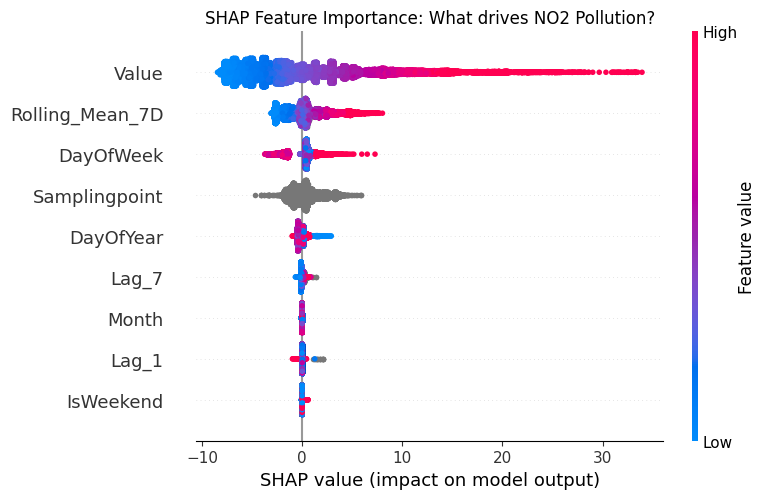

In [30]:
# Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(best_model) # For XGBoost use TreeExplaienr

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title(f"SHAP Feature Importance: What drives {POLLUTANT} Pollution?")
plt.tight_layout()
plt.savefig(output_dir / f"{RUN_ID}_SHAP_Feature_importance.png", bbox_inches='tight')
plt.show()

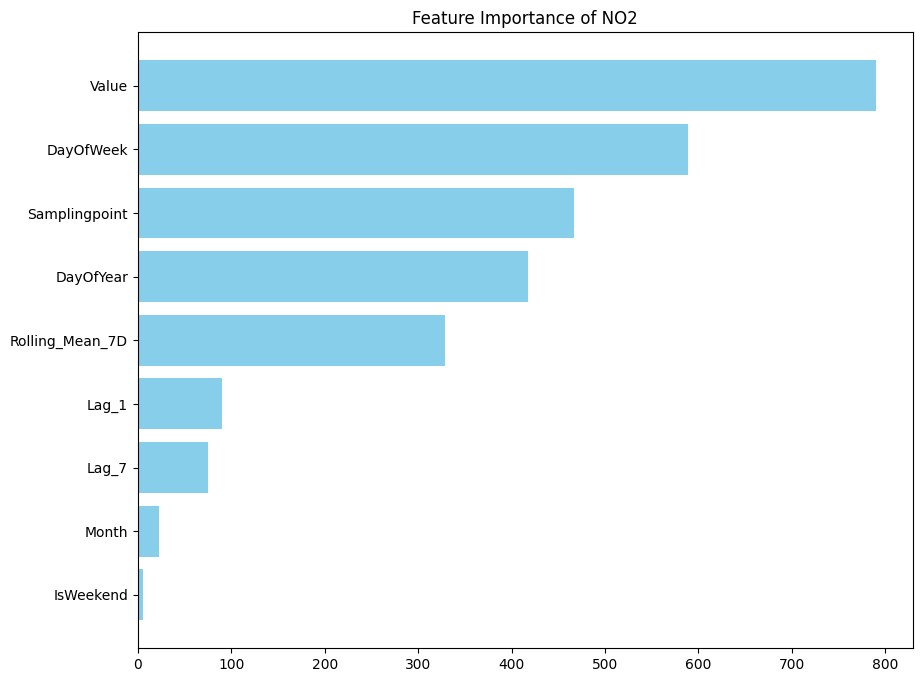

In [31]:
importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)


top_n = 20
plt.figure(figsize=(10, 8))
plt.title(f"Feature Importance of {POLLUTANT}")
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.savefig(output_dir / f"{RUN_ID}_Feature_Importance.png", bbox_inches='tight')

RMSE: 6.3788
MAE:  4.4869
R2:   0.7036
Samplingpoint IE/SPO.IE.IE001APSample2_8 -> RMSE: 6.85 | MAE: 5.41 | R2: 0.43


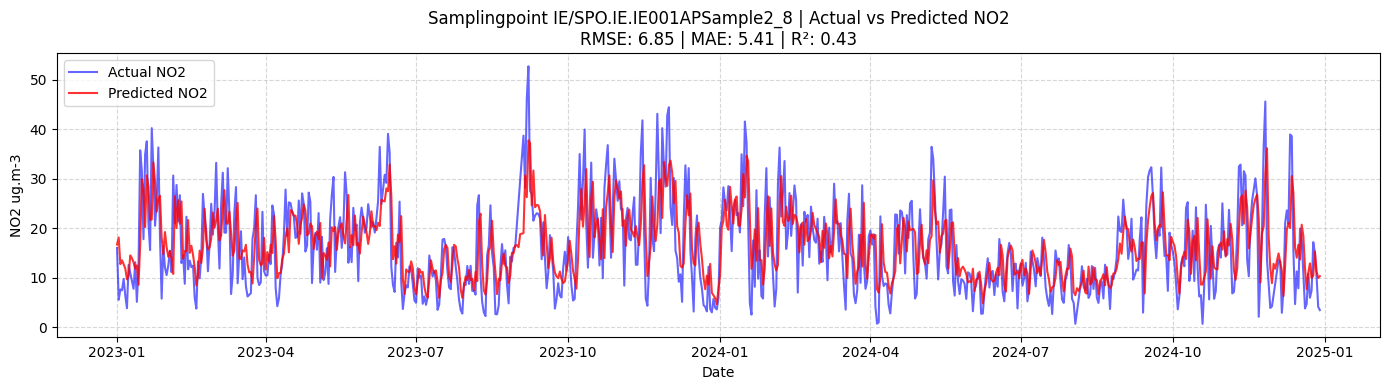

Samplingpoint IE/SPO.IE.IE007GYSample2_8 -> RMSE: 5.01 | MAE: 3.82 | R2: 0.46


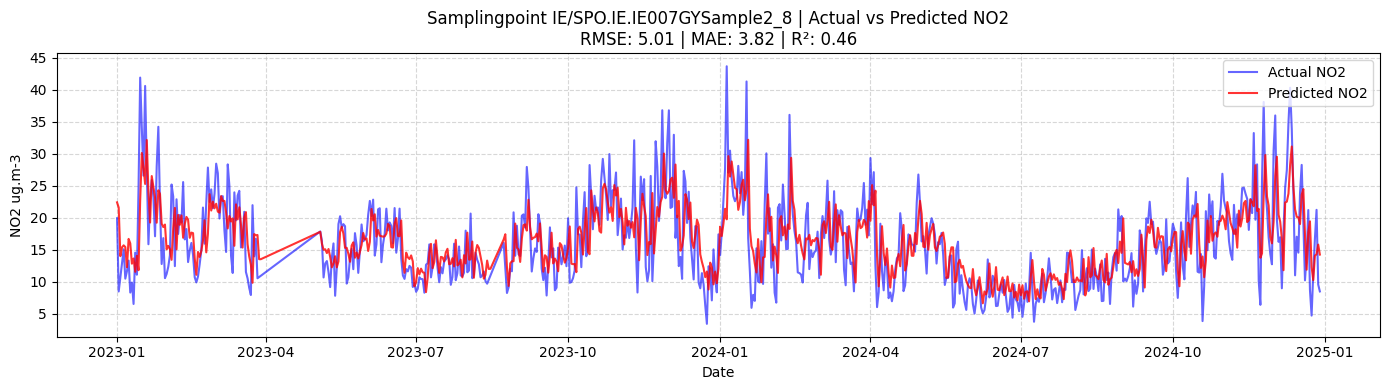

Samplingpoint IE/SPO.IE.IE0118ASample1_8 -> RMSE: 3.51 | MAE: 2.33 | R2: 0.46


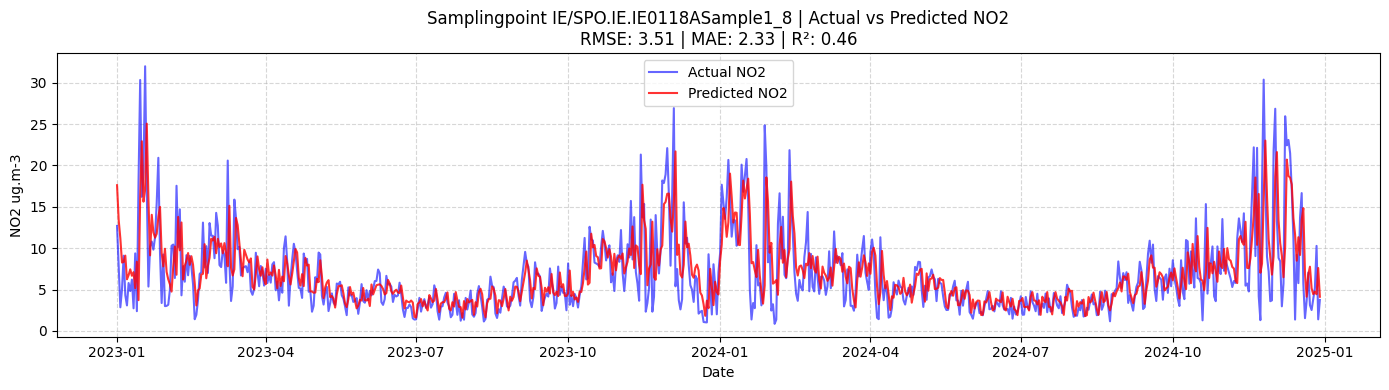

Samplingpoint IE/SPO.IE.IE002BPSample1_8 -> RMSE: 4.80 | MAE: 3.81 | R2: -0.12


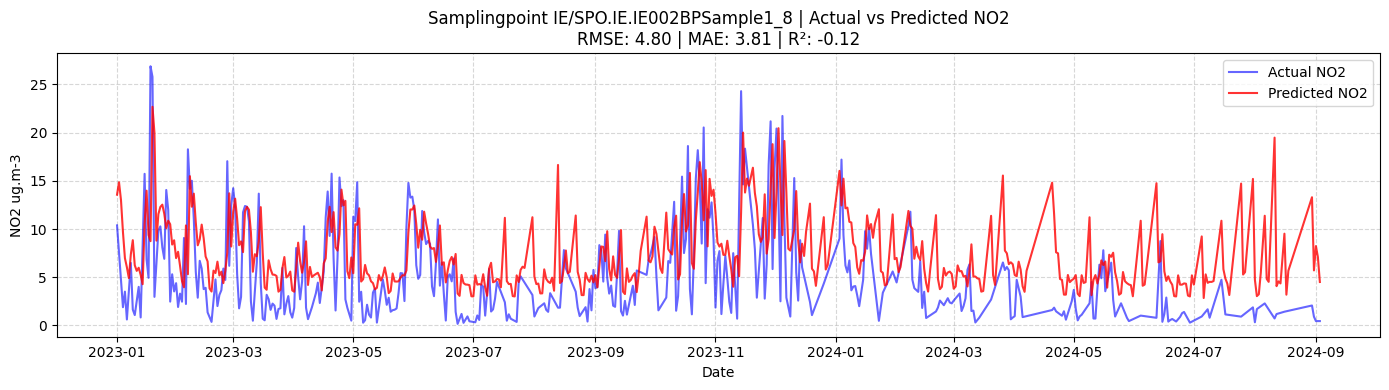

Samplingpoint IE/SPO.IE.IE002CMSample1_8 -> RMSE: 4.17 | MAE: 3.04 | R2: 0.40


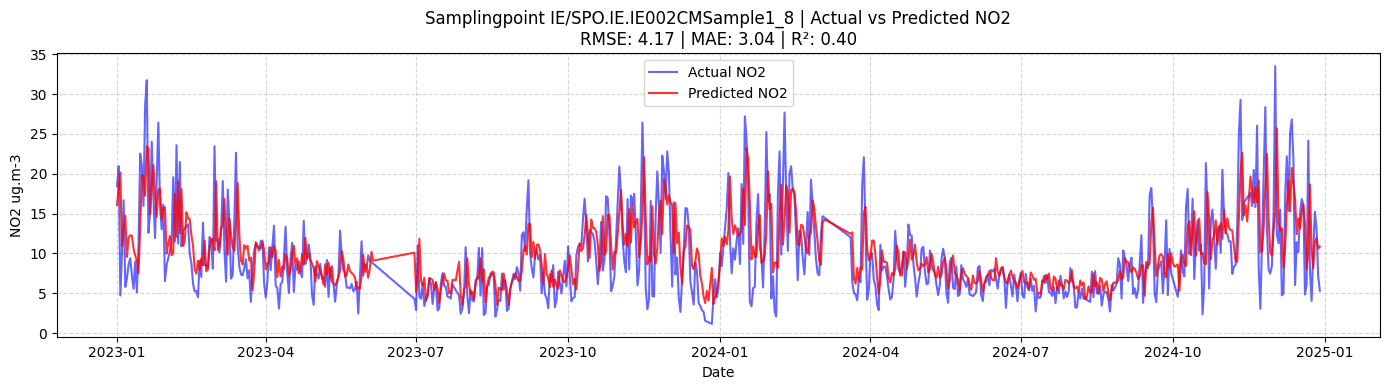

Samplingpoint IE/SPO.IE.IE0111ASample1_8 -> RMSE: 1.71 | MAE: 1.25 | R2: 0.28


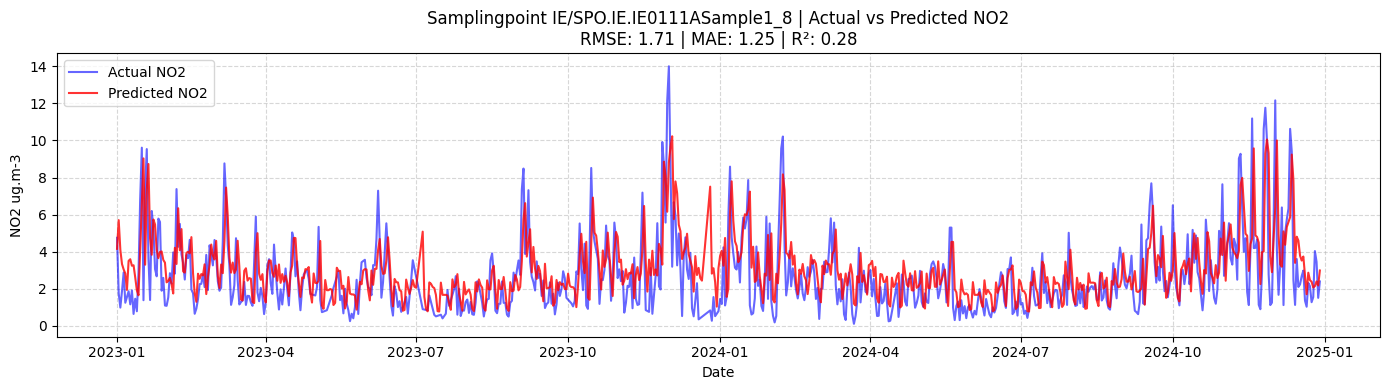

Samplingpoint IE/SPO.IE.IE012CKSample2_8 -> RMSE: 4.56 | MAE: 3.52 | R2: 0.36


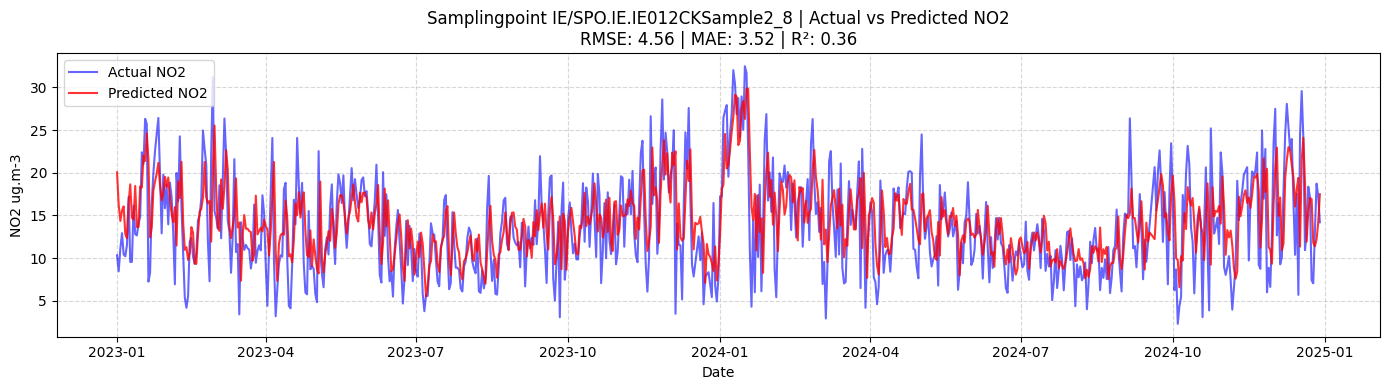

Samplingpoint IE/SPO.IE.IE0036ASample1_8 -> RMSE: 6.50 | MAE: 5.01 | R2: 0.35


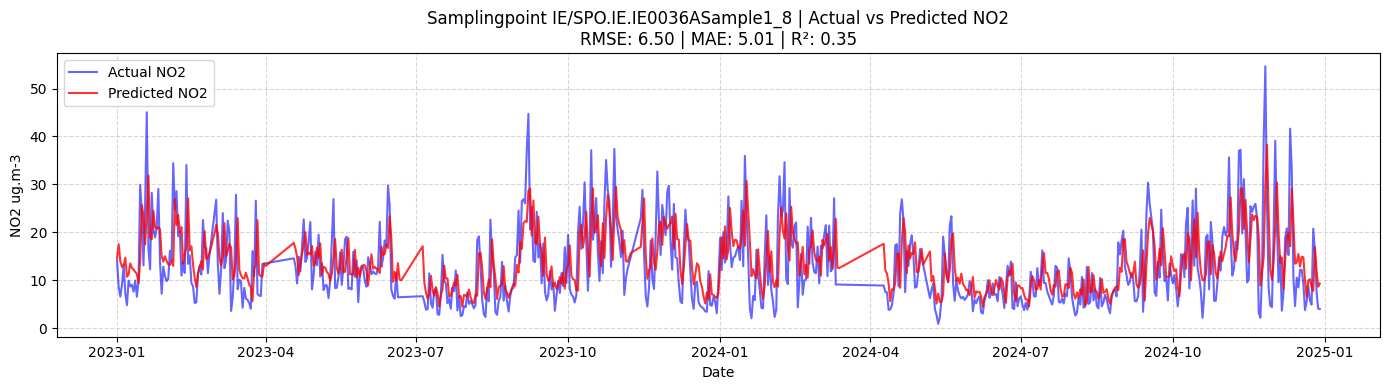

Samplingpoint IE/SPO.IE.IE005APSample2_8 -> RMSE: 9.96 | MAE: 7.60 | R2: 0.43


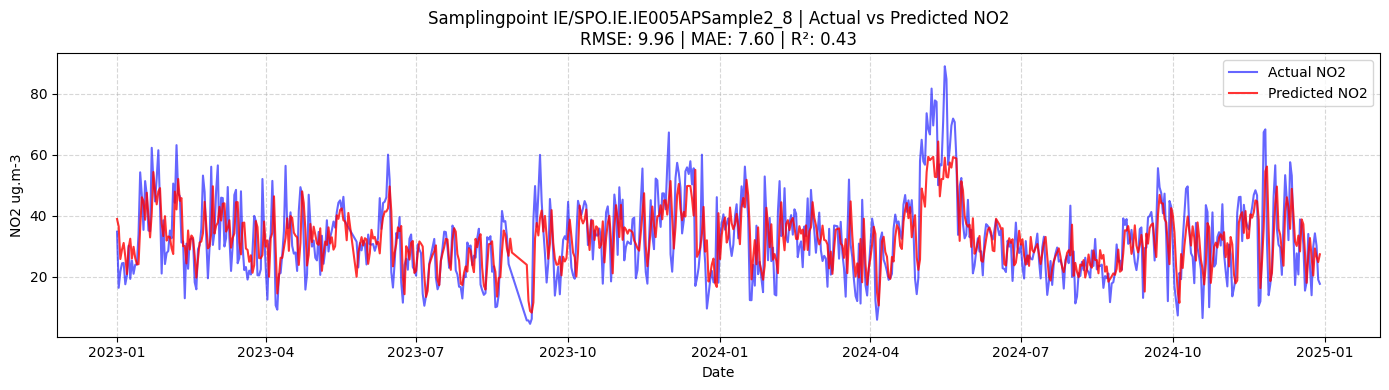

Samplingpoint IE/SPO.IE.IE001LMSample1_8 -> RMSE: 4.73 | MAE: 3.54 | R2: 0.42


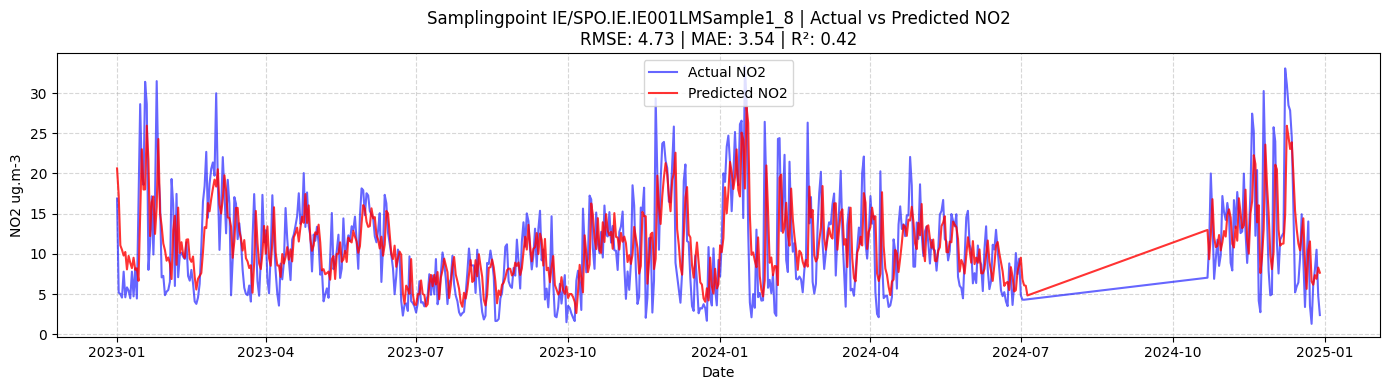

Samplingpoint IE/SPO.IE.IE0028ASample1_8 -> RMSE: 6.06 | MAE: 4.71 | R2: 0.43


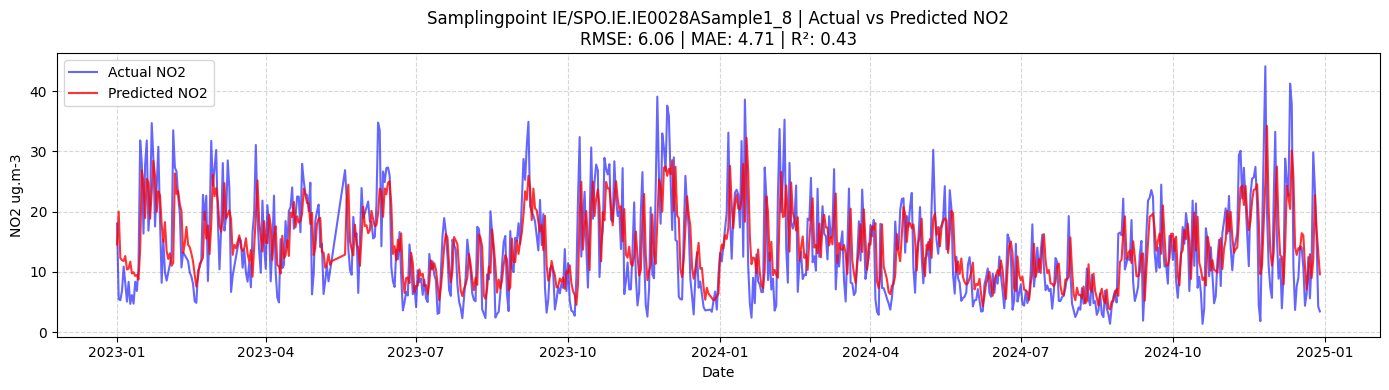

Samplingpoint IE/SPO.IE.IE027DSample2_8 -> RMSE: 6.95 | MAE: 5.32 | R2: 0.32


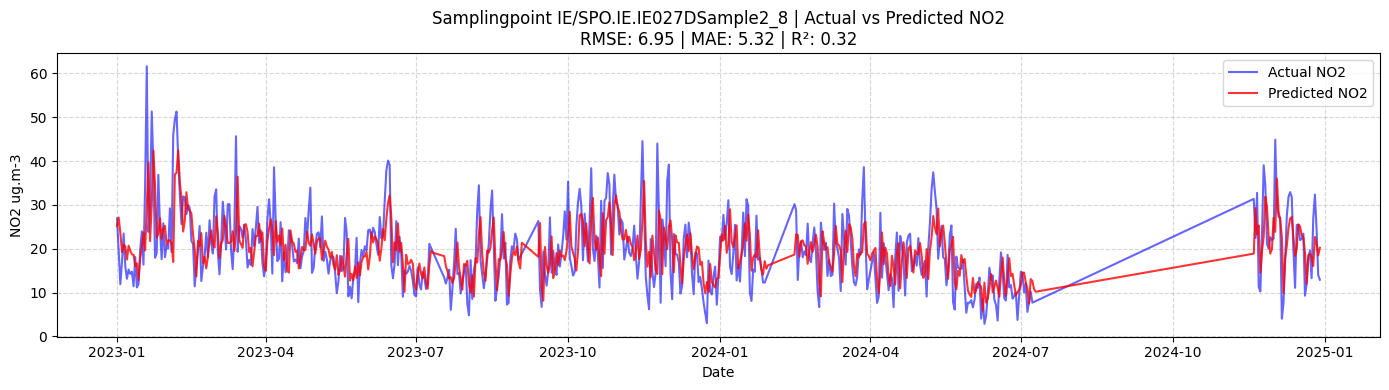

Samplingpoint IE/SPO.IE.IE008CPSample1_8 -> RMSE: 8.04 | MAE: 6.02 | R2: 0.37


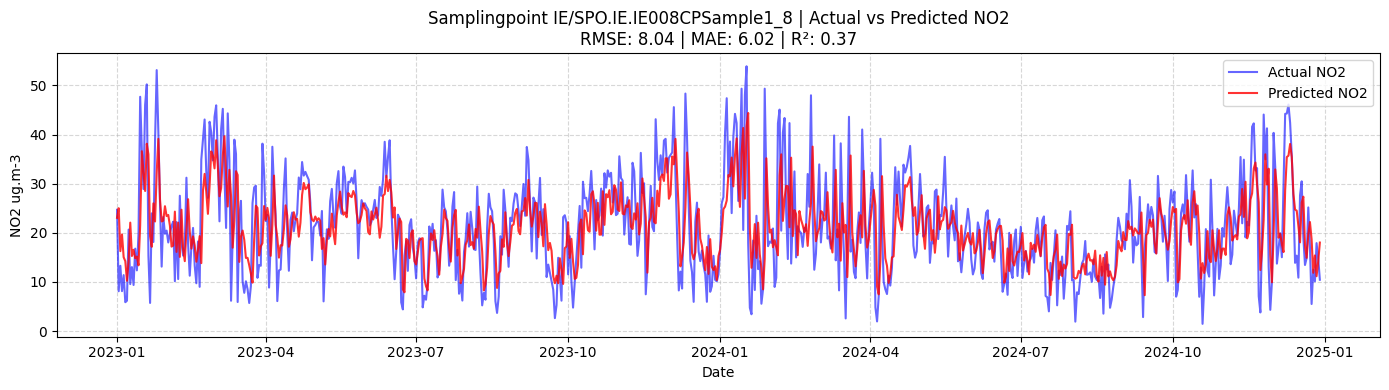

Samplingpoint IE/SPO.IE.IE0136ASample1_8 -> RMSE: 6.11 | MAE: 4.68 | R2: 0.36


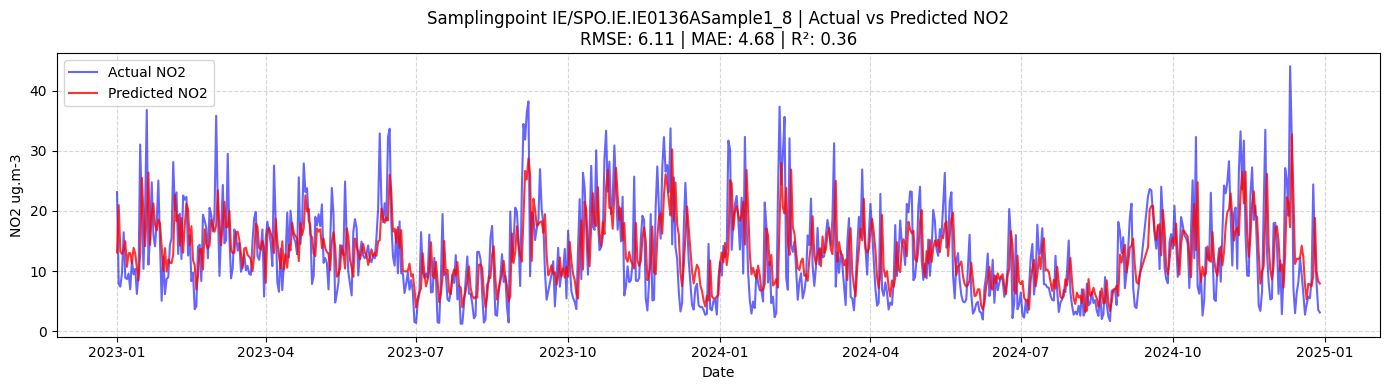

Samplingpoint IE/SPO.IE.IE0147ASample1_8 -> RMSE: 2.87 | MAE: 1.91 | R2: 0.43


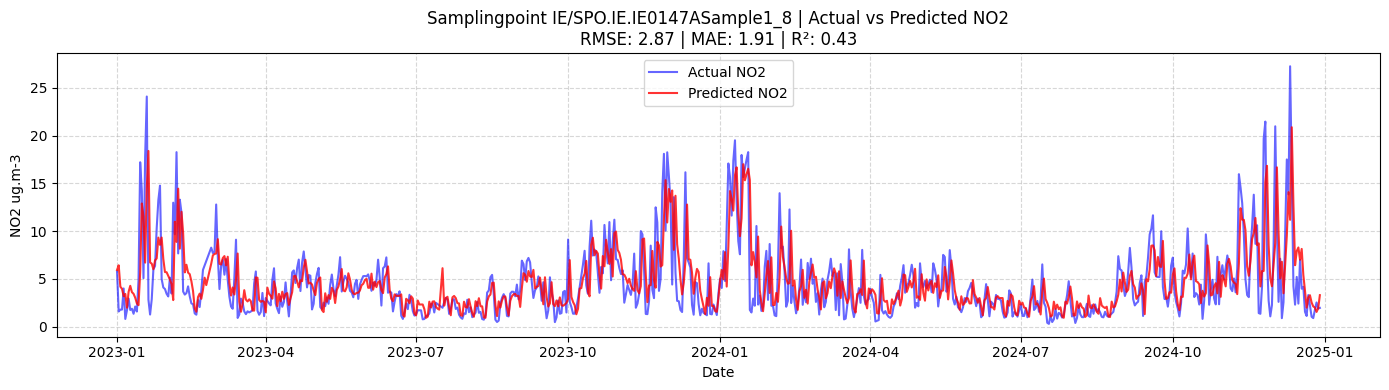

Samplingpoint IE/SPO.IE.IE009GYSample1_8 -> RMSE: 8.07 | MAE: 6.18 | R2: 0.22


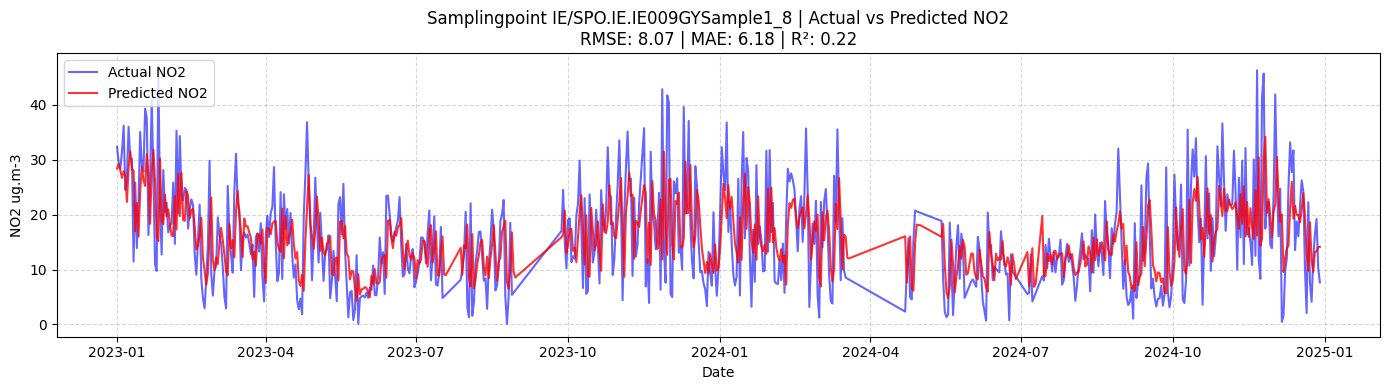

Samplingpoint IE/SPO.IE.IE004BPSample2_8 -> RMSE: 2.80 | MAE: 1.89 | R2: 0.40


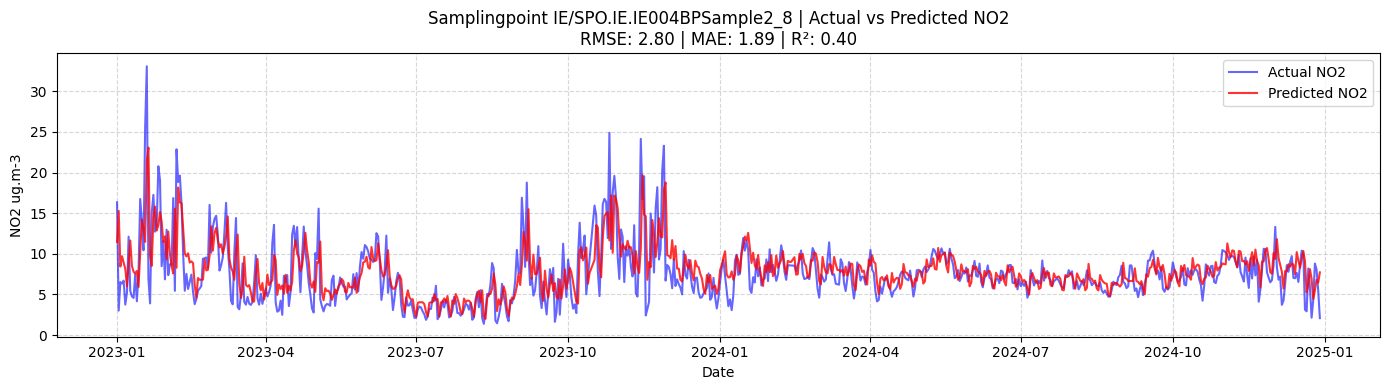

Samplingpoint IE/SPO.IE.IE0131ASample1_8 -> RMSE: 10.25 | MAE: 8.09 | R2: 0.42


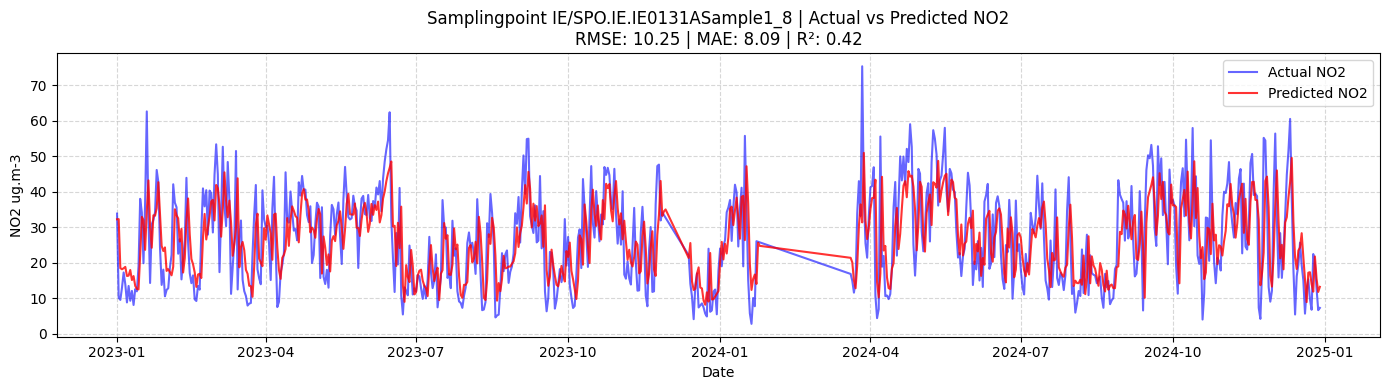

Samplingpoint IE/SPO.IE.IE007CPSample2_8 -> RMSE: 4.29 | MAE: 3.05 | R2: 0.45


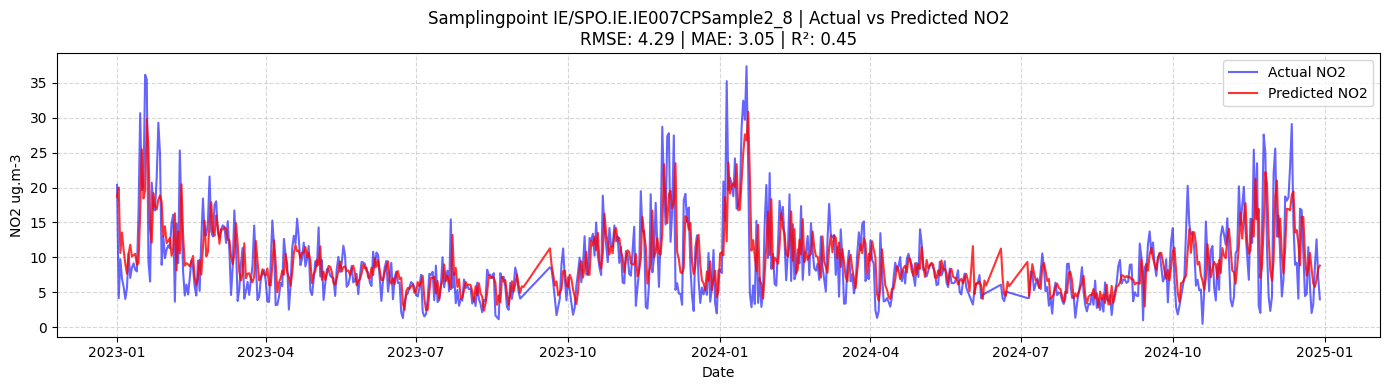

Samplingpoint IE/SPO.IE.IE0140ASample1_8 -> RMSE: 5.01 | MAE: 3.89 | R2: 0.23


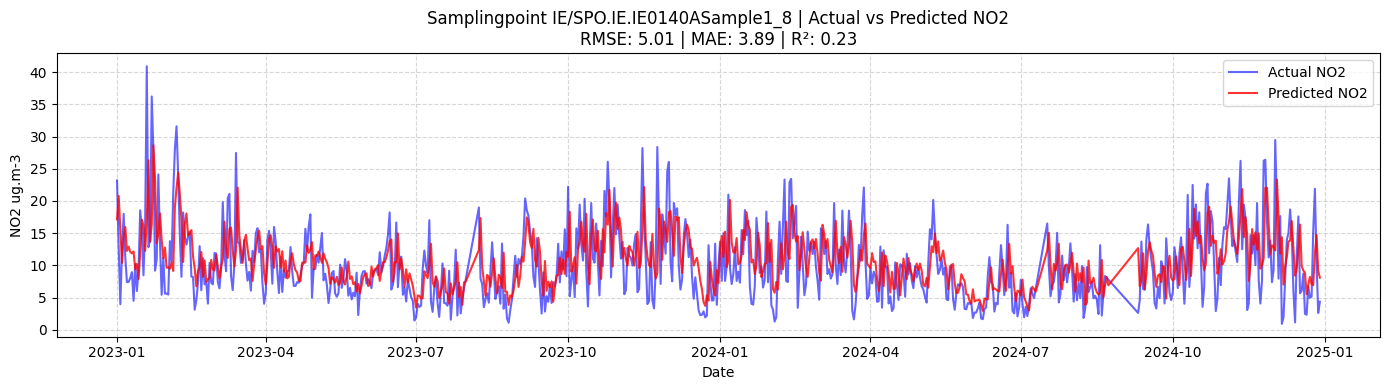

Samplingpoint IE/SPO.IE.IE010LKSample2_8 -> RMSE: 5.35 | MAE: 4.08 | R2: 0.39


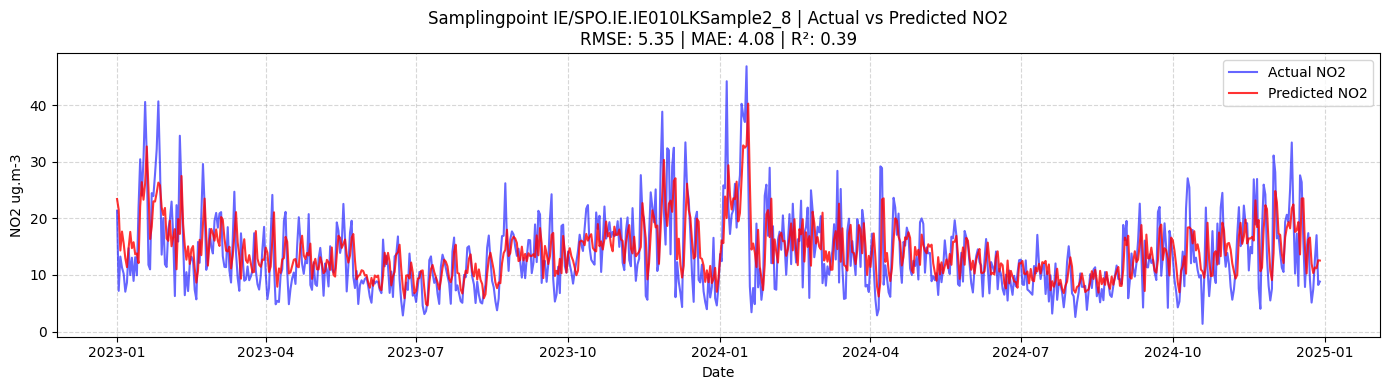

Samplingpoint IE/SPO.IE.IE0030DSample1_8 -> RMSE: 7.92 | MAE: 6.01 | R2: 0.32


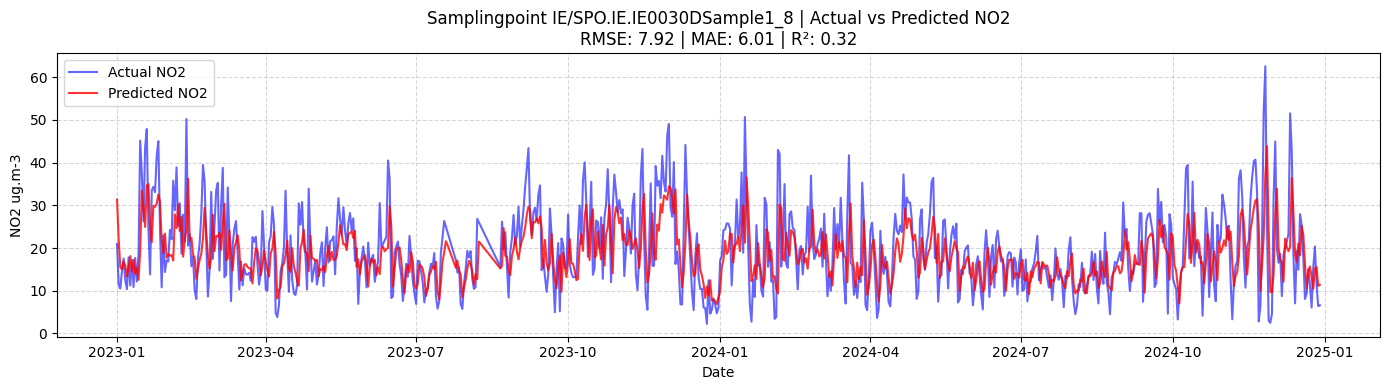

Samplingpoint IE/SPO.IE.IE0132ASample1_8 -> RMSE: 5.96 | MAE: 4.44 | R2: 0.30


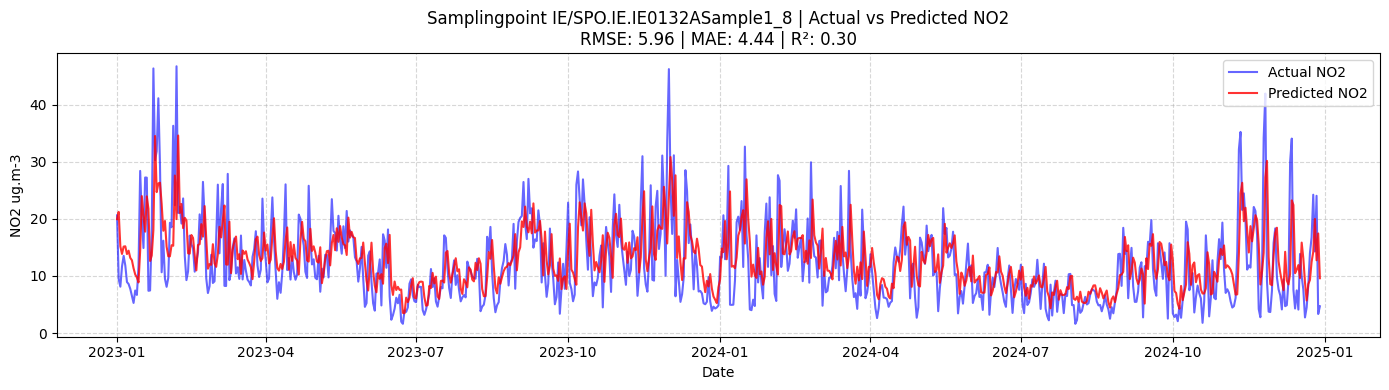

Samplingpoint IE/SPO.IE.IE001CMSample1_8 -> RMSE: 3.72 | MAE: 2.75 | R2: 0.46


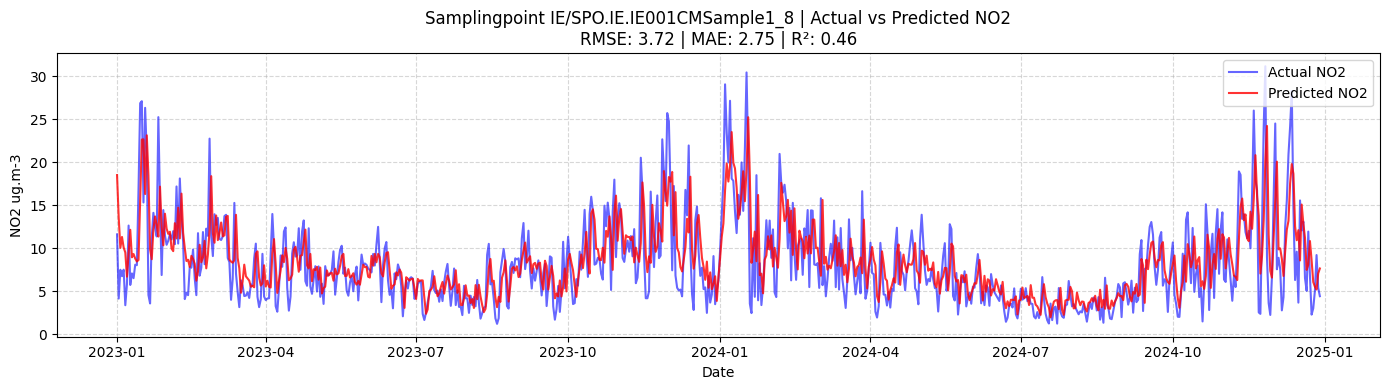

Samplingpoint IE/SPO.IE.IE028DSample2_8 -> RMSE: 8.53 | MAE: 6.73 | R2: 0.43


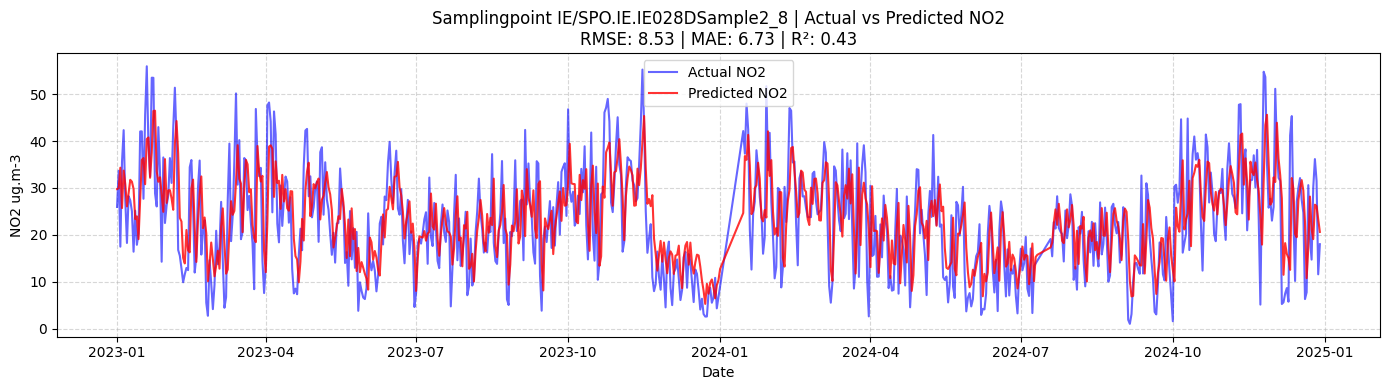

Samplingpoint IE/SPO.IE.IE001BPSample1_8 -> RMSE: 6.68 | MAE: 5.02 | R2: 0.34


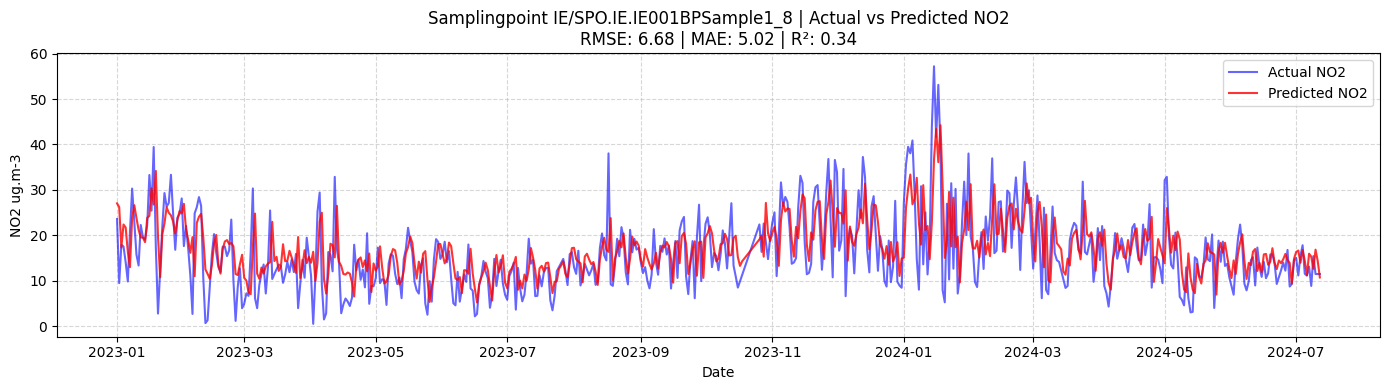

Samplingpoint IE/SPO.IE.IE0090ASample1_8 -> RMSE: 1.55 | MAE: 1.00 | R2: -0.87


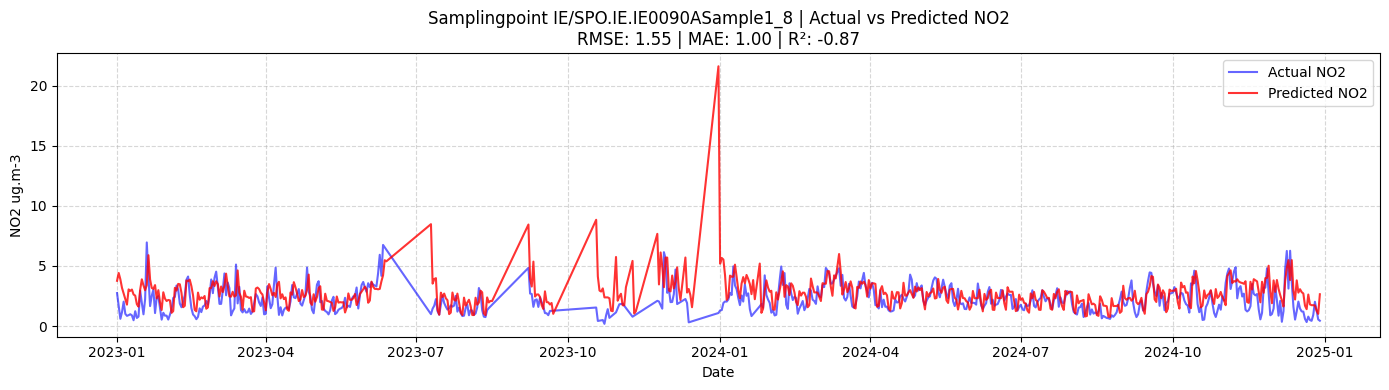

Samplingpoint IE/SPO.IE.IE005CPSample2_8 -> RMSE: 3.57 | MAE: 2.47 | R2: 0.44


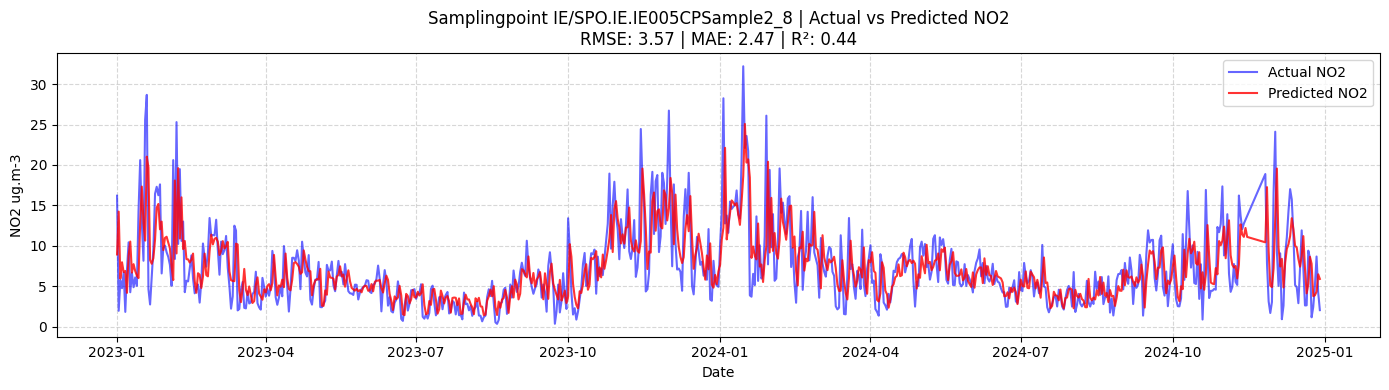

Samplingpoint IE/SPO.IE.IE004APSample1_8 -> RMSE: 7.75 | MAE: 6.15 | R2: 0.45


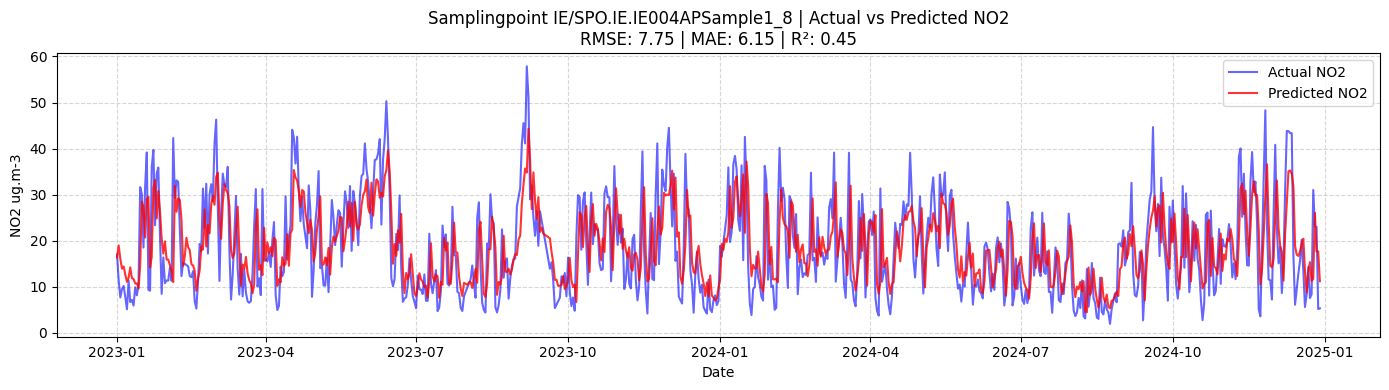

Samplingpoint IE/SPO.IE.IE013CKSample2_8 -> RMSE: 7.68 | MAE: 5.92 | R2: 0.57


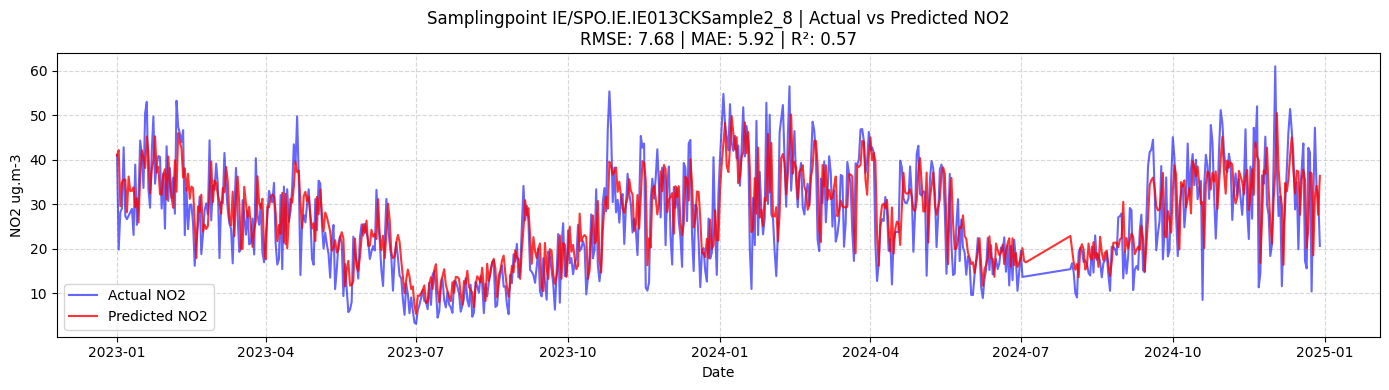

Samplingpoint IE/SPO.IE.IE0098ASample1_8 -> RMSE: 6.85 | MAE: 5.02 | R2: 0.49


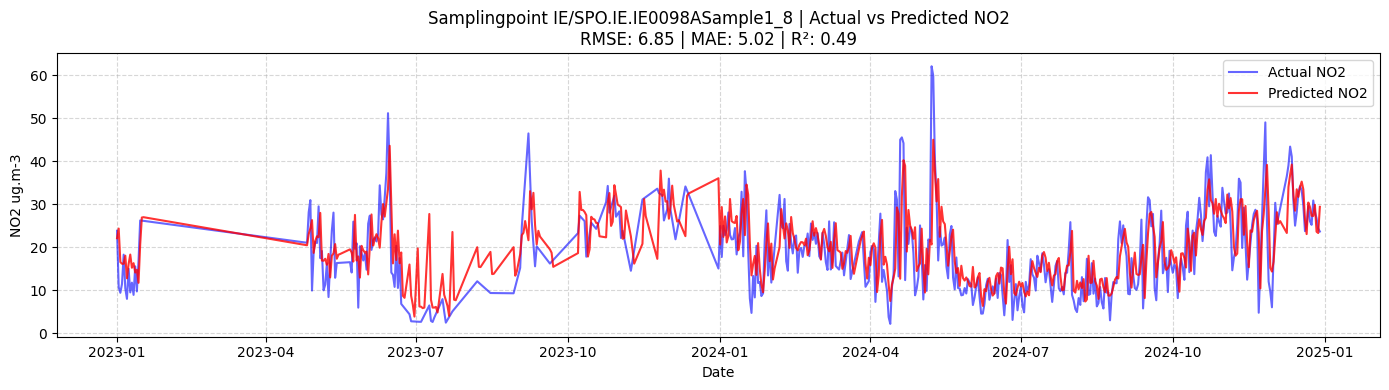

Samplingpoint IE/SPO.IE.IE006APSample1_8 -> RMSE: 9.15 | MAE: 7.27 | R2: 0.41


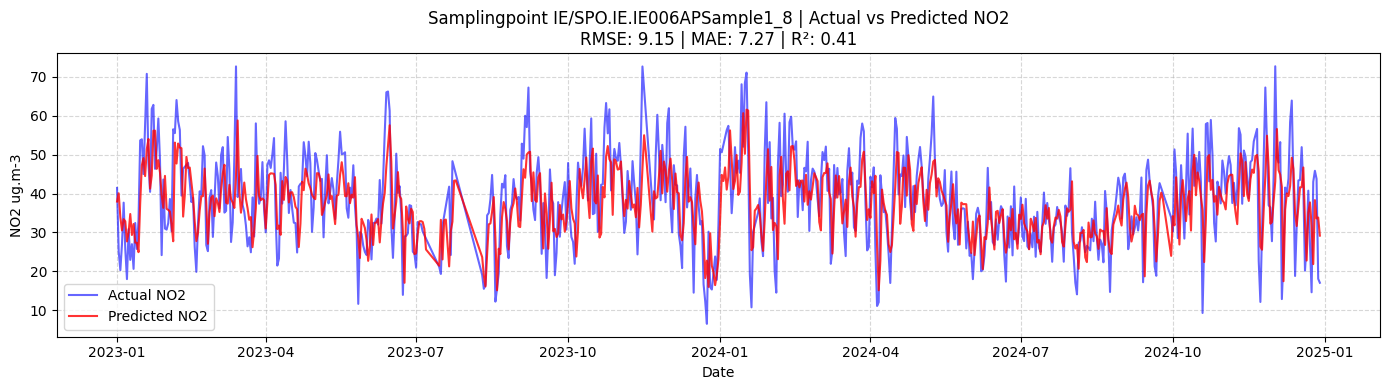

Samplingpoint IE/SPO.IE.IE001WDSample1_8 -> RMSE: 5.46 | MAE: 3.92 | R2: 0.39


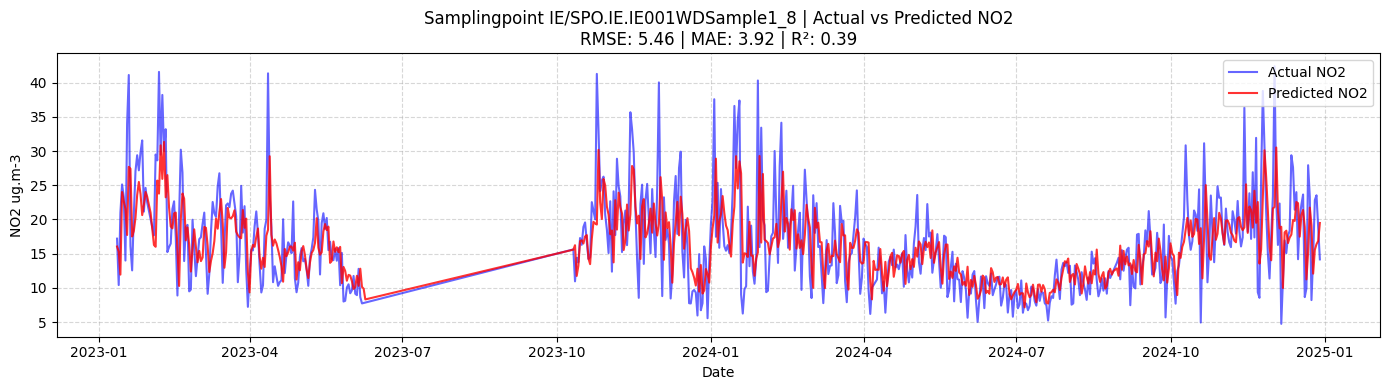

Samplingpoint IE/SPO.IE.IE005OYSample2_8 -> RMSE: 3.81 | MAE: 2.81 | R2: 0.50


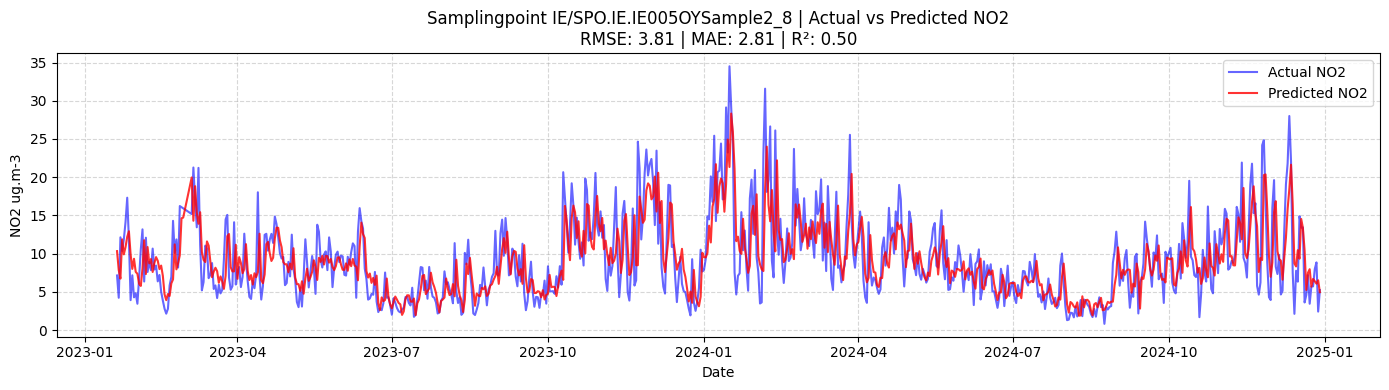

Samplingpoint IE/SPO.IE.IE009DPSample1_8 -> RMSE: 4.99 | MAE: 3.82 | R2: 0.40


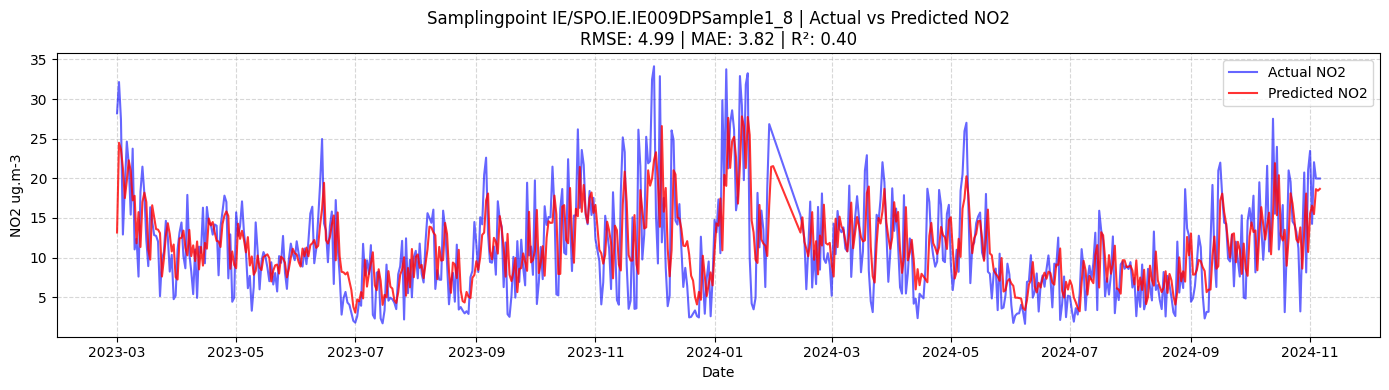

Samplingpoint IE/SPO.IE.IE0029DSample1_8 -> RMSE: 13.38 | MAE: 10.70 | R2: 0.17


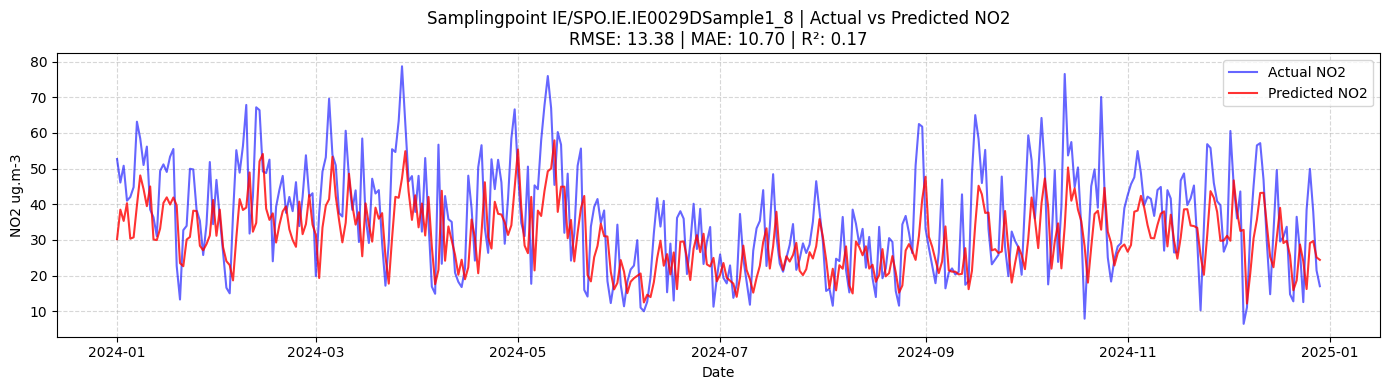

Samplingpoint IE/SPO.IE.IE002SOSample1_8 -> RMSE: 10.05 | MAE: 7.47 | R2: 0.35


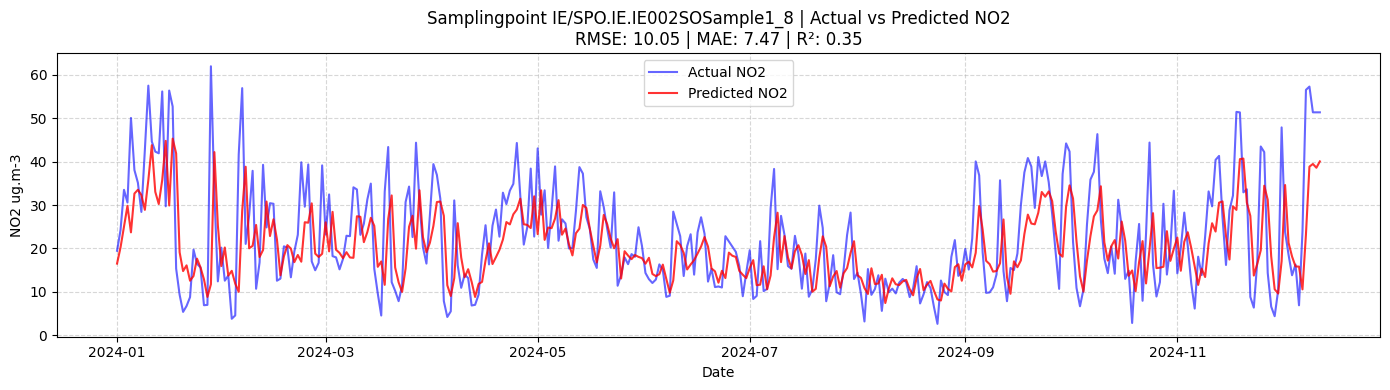

In [32]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


# folder for these prediction plots
pred_plot_dir = output_dir / "Predict_vs_Actual_Plots"
pred_plot_dir.mkdir(parents=True, exist_ok=True)

# Plotting Actual vs Predicted for each station in the Test Set
results_df = test_data.copy() # already grouped staion and start (date)
results_df['Actual'] = y_test
results_df['Predicted'] = test_preds


stations = results_df['Samplingpoint'].unique() 

station_metrics_list = [] 

for station in stations:
    station_data = results_df[results_df['Samplingpoint'] == station] 
    
    # skip stations with not enough data to calculate R2 for the stations that have shut down/little test data
    if len(station_data) < 2:
        continue
        
    st_rmse = np.sqrt(mean_squared_error(station_data['Actual'], station_data['Predicted']))
    st_mae = mean_absolute_error(station_data['Actual'], station_data['Predicted'])
    st_r2 = r2_score(station_data['Actual'], station_data['Predicted'])

    station_metrics_list.append({ # add evalutation to list
        'Station': station,
        'RMSE': round(st_rmse, 3),
        'MAE': round(st_mae, 3),
        'R2': round(st_r2, 3)
    })
    
    print(f"Samplingpoint {station} -> RMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R2: {st_r2:.2f}")
    

    plt.figure(figsize=(14, 4))
    
    # Using 'Start' for the x-axis datetime timeline
    plt.plot(station_data['Start'], station_data['Actual'], label=f'Actual {POLLUTANT}', color='blue', alpha=0.6)
    plt.plot(station_data['Start'], station_data['Predicted'], label=f'Predicted {POLLUTANT}', color='red', alpha=0.8, linewidth=1.5)
    
    plt.title(f'Samplingpoint {station} | Actual vs Predicted {POLLUTANT}\nRMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R²: {st_r2:.2f}')
    plt.xlabel('Date')
    plt.ylabel(f'{POLLUTANT} ug.m-3')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_predict.png"
    plt.savefig(pred_plot_dir / file_name, dpi=150)

    plt.show()
    plt.close()


# list to df to csv
metrics_df = pd.DataFrame(station_metrics_list)
csv_filename = output_dir / f"{COUNTRY_CODE}_{POLLUTANT}_Every_Station_Metrics.csv"
metrics_df.to_csv(csv_filename, index=False)